In [1]:
!pip install -q --upgrade pip
!pip install -q pandas numpy matplotlib pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 12.7 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import pandas as pd
from google.colab import drive

drive.mount("/content/drive")
RAW_BACKUP = Path("/content/drive/MyDrive/energy-forecast/raw")
if not Path("/content/data").exists():
    !cp -r "$RAW_BACKUP" /content/data
    print("Restored raw dataset from Drive")

DATA = Path("/content/data")

all_csv = sorted(DATA.rglob("block_*.csv"))
print(f"All block_*.csv under /content/data: {len(all_csv)}")
for d in sorted({p.relative_to(DATA).parts[0] for p in all_csv}):
    n = sum(1 for p in all_csv if p.relative_to(DATA).parts[0] == d)
    print(f"  {d}: {n} files")

block_files = [p for p in all_csv if p.parts[-3] == "halfhourly_dataset"]
assert len(block_files) == 112, f"expected 112 half-hourly blocks, got {len(block_files)}"
print(f"Using half-hourly block files: {len(block_files)}")
print(block_files[0])

households = pd.read_csv(DATA / "informations_households.csv")
std_ids = set(households.loc[households["stdorToU"] == "Std", "LCLid"])
print(f"Std-tariff households: {len(std_ids):,} / {len(households):,}")


Mounted at /content/drive
Restored raw dataset from Drive
All block_*.csv under /content/data: 336
  daily_dataset: 112 files
  halfhourly_dataset: 112 files
  hhblock_dataset: 112 files
Using half-hourly block files: 112
/content/data/halfhourly_dataset/halfhourly_dataset/block_0.csv
Std-tariff households: 4,443 / 5,566


In [3]:
import numpy as np

REQUIRED_COLS = {"LCLid", "tstp", "energy(kWh/hh)"}

def process_block(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, dtype={"LCLid": "string", "tstp": "string", "energy(kWh/hh)": "string"})
    missing = REQUIRED_COLS - set(df.columns)
    if missing:
        raise ValueError(f"{path.name}: wrong schema, missing {missing} (has: {df.columns.tolist()})")
    df = df[df["LCLid"].isin(std_ids)]
    df["ts"] = pd.to_datetime(df["tstp"], errors="coerce", utc=True)
    df["energy"] = pd.to_numeric(df["energy(kWh/hh)"], errors="coerce")
    df = df.dropna(subset=["ts", "energy"])
    df = df.drop_duplicates(subset=["LCLid", "ts"])

    df["hour"] = df["ts"].dt.floor("h")
    hh = (
        df.groupby(["LCLid", "hour"], observed=True)["energy"]
        .sum()
        .reset_index()
    )
    out = (
        hh.groupby("hour")["energy"]
        .agg(demand_sum="sum", demand_mean="mean", n_households="count")
        .reset_index()
    )
    return out

parts = []
for i, path in enumerate(block_files):
    parts.append(process_block(path))
    if (i + 1) % 20 == 0:
        print(f"{i + 1}/{len(block_files)} blocks done")

hourly = (
    pd.concat(parts, ignore_index=True)
    .groupby("hour")
    .agg(demand_sum=("demand_sum", "sum"), n_households=("n_households", "sum"))
    .reset_index()
)
hourly["demand"] = hourly["demand_sum"] / hourly["n_households"]
hourly = hourly.drop(columns="demand_sum").sort_values("hour").reset_index(drop=True)
print(hourly.shape)
hourly.head()


20/112 blocks done
40/112 blocks done
60/112 blocks done
80/112 blocks done
100/112 blocks done
(19864, 3)


,hour,n_households,demand
0,2011-11-23 09:00:00+00:00,1,0.769
1,2011-11-23 10:00:00+00:00,4,0.28825
2,2011-11-23 11:00:00+00:00,5,0.3436
3,2011-11-23 12:00:00+00:00,8,0.742375
4,2011-11-23 13:00:00+00:00,11,0.514909


In [4]:
full_idx = pd.date_range(hourly["hour"].min(), hourly["hour"].max(), freq="h", tz="UTC")
hourly = hourly.set_index("hour").reindex(full_idx).rename_axis("hour").reset_index()

gaps = hourly["demand"].isna()
print(f"Total hours: {len(hourly):,}")
print(f"Hours with no readings at all: {int(gaps.sum()):,}")
print(f"n_households: min {int(hourly['n_households'].min())}, "
      f"median {int(hourly['n_households'].median())}, max {int(hourly['n_households'].max())}")

gap_runs = gaps.astype(int).groupby((~gaps).cumsum()).sum()
long_gaps = gap_runs[gap_runs > 24]
print(f"Gap runs longer than 24h: {len(long_gaps)} (max {int(gap_runs.max())}h)")

Total hours: 19,864
Hours with no readings at all: 0
n_households: min 1, median 4085, max 4416
Gap runs longer than 24h: 0 (max 0h)


In [5]:
weather = pd.read_csv(DATA / "weather_hourly_darksky.csv")
weather["hour"] = pd.to_datetime(weather["time"], errors="coerce", utc=True).dt.floor("h")
wx_cols = ["temperature", "apparentTemperature", "humidity", "windSpeed", "dewPoint", "pressure", "visibility"]
weather = weather[["hour"] + wx_cols].drop_duplicates("hour")
for c in wx_cols:
    weather[c] = pd.to_numeric(weather[c], errors="coerce")
    weather[c] = weather[c].interpolate(limit_direction="both")

df = hourly.merge(weather, on="hour", how="left")
print(df.shape)
print("Weather NaNs after merge:", int(df[wx_cols].isna().any(axis=1).sum()))
df.head(3)

(19864, 10)
Weather NaNs after merge: 2


,hour,n_households,demand,temperature,apparentTemperature,humidity,windSpeed,dewPoint,pressure,visibility
0,2011-11-23 09:00:00+00:00,1,0.769,4.84,3.42,0.99,1.78,4.68,1027.29,4.39
1,2011-11-23 10:00:00+00:00,4,0.28825,5.74,4.24,0.98,1.99,5.46,1027.67,6.24
2,2011-11-23 11:00:00+00:00,5,0.3436,7.67,5.94,0.88,2.66,5.74,1027.56,10.20


In [6]:
from google.colab import drive
drive.mount("/content/drive")

OUT_DIR = "/content/drive/MyDrive/energy-forecast"
!mkdir -p "$OUT_DIR"
df.to_parquet(f"{OUT_DIR}/aggregate_hourly.parquet", index=False)
df.to_parquet("/content/aggregate_hourly.parquet", index=False)
print("Saved:", f"{OUT_DIR}/aggregate_hourly.parquet")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved: /content/drive/MyDrive/energy-forecast/aggregate_hourly.parquet


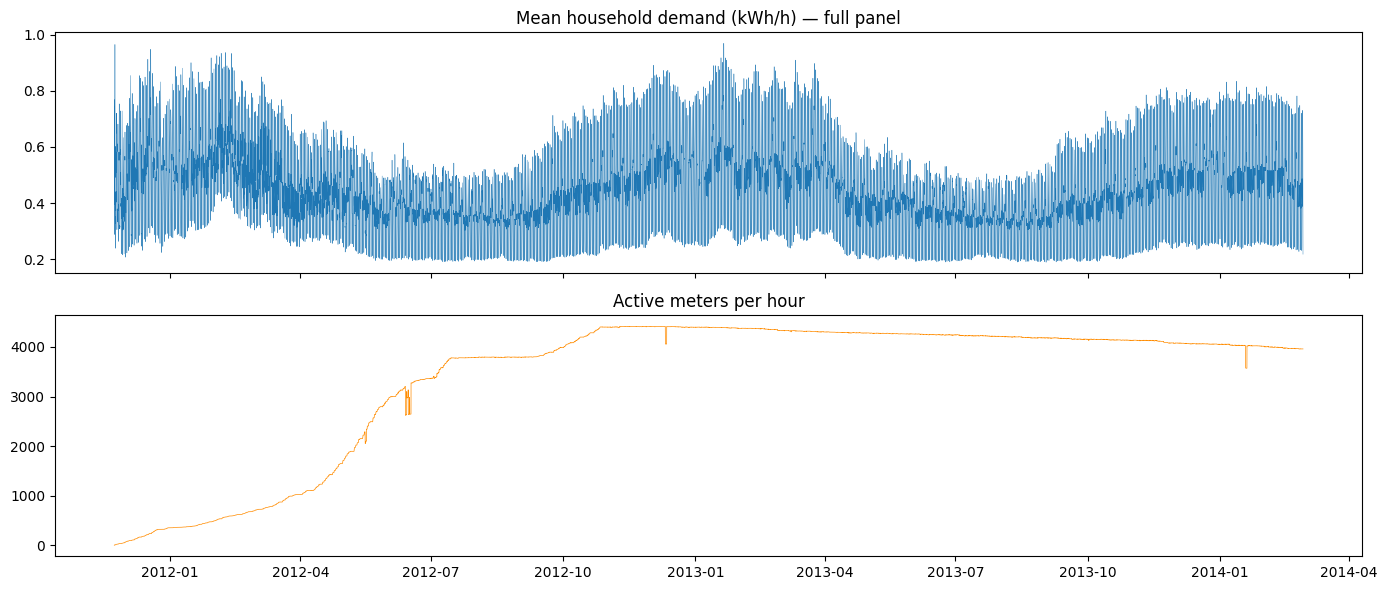

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(df["hour"], df["demand"], lw=0.3)
axes[0].set_title("Mean household demand (kWh/h) — full panel")
axes[1].plot(df["hour"], df["n_households"], lw=0.5, color="darkorange")
axes[1].set_title("Active meters per hour")
plt.tight_layout()
plt.show()

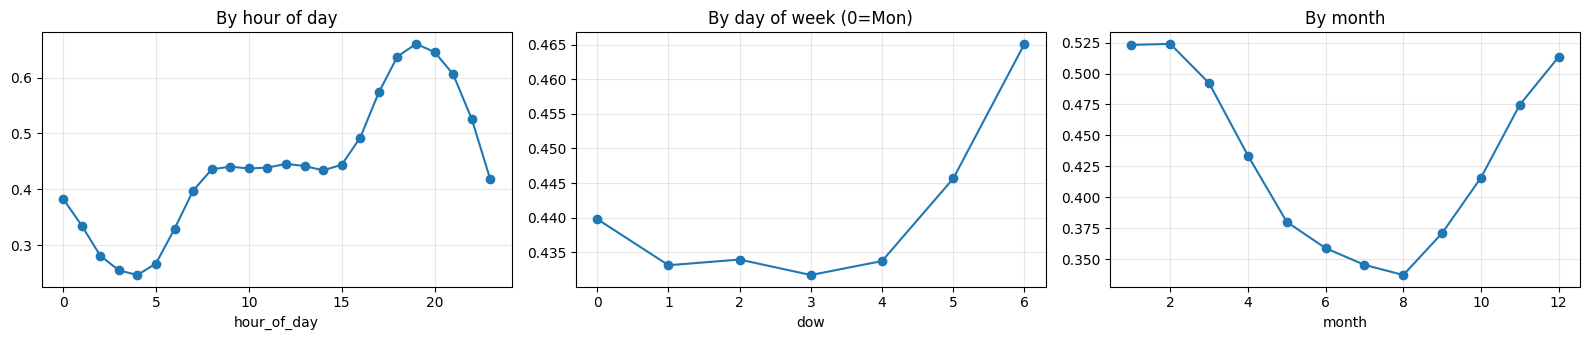

Weekday mean: 0.4344
Weekend mean: 0.4554


In [8]:
d = df.dropna(subset=["demand"]).copy()
d["hour_of_day"] = d["hour"].dt.hour
d["dow"] = d["hour"].dt.dayofweek
d["month"] = d["hour"].dt.month
d["is_weekend"] = d["dow"] >= 5

fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))
d.groupby("hour_of_day")["demand"].mean().plot(ax=axes[0], marker="o", title="By hour of day")
d.groupby("dow")["demand"].mean().plot(ax=axes[1], marker="o", title="By day of week (0=Mon)")
d.groupby("month")["demand"].mean().plot(ax=axes[2], marker="o", title="By month")
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Weekday mean:", round(d.loc[~d["is_weekend"], "demand"].mean(), 4))
print("Weekend mean:", round(d.loc[d["is_weekend"], "demand"].mean(), 4))

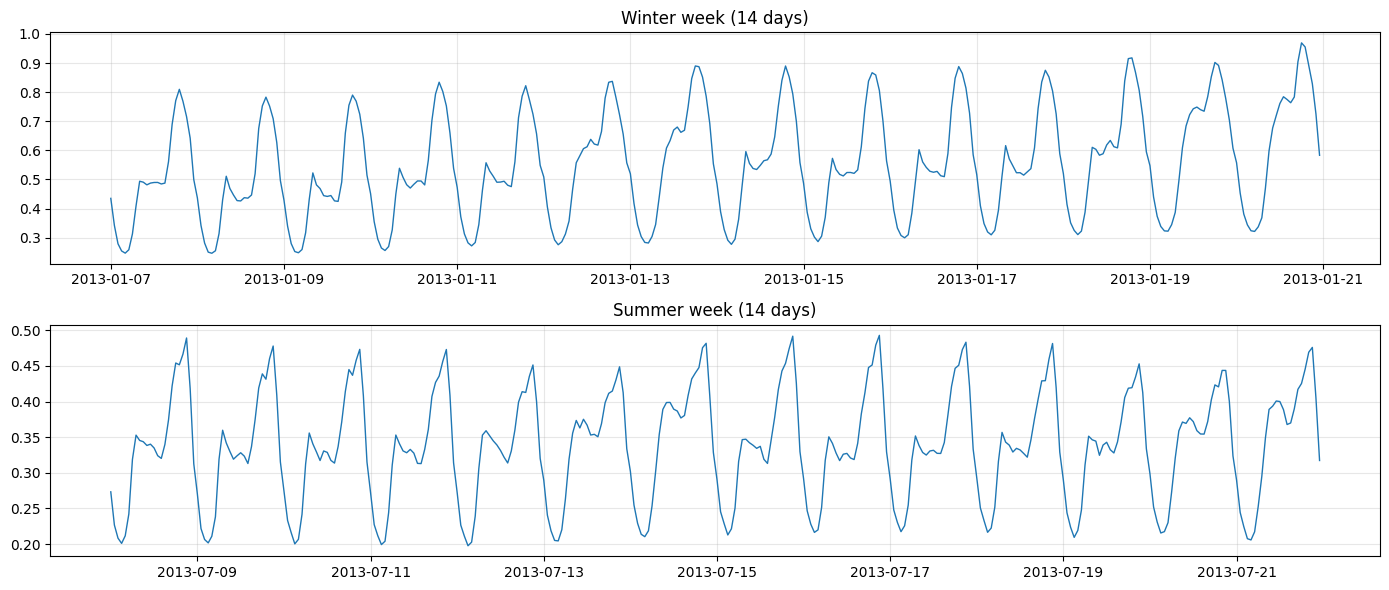

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)
for ax, (label, start) in zip(axes, [("Winter week", "2013-01-07"), ("Summer week", "2013-07-08")]):
    start_ts = pd.Timestamp(start, tz="UTC")
    wk = d[(d["hour"] >= start_ts) & (d["hour"] < start_ts + pd.Timedelta(days=14))]
    ax.plot(wk["hour"], wk["demand"], lw=1.0)
    ax.set_title(f"{label} (14 days)")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Lag autocorrelation:
  lag    1h: 0.934
  lag    2h: 0.782
  lag   24h: 0.964
  lag   48h: 0.939
  lag   72h: 0.929
  lag  168h: 0.958
  lag  336h: 0.937


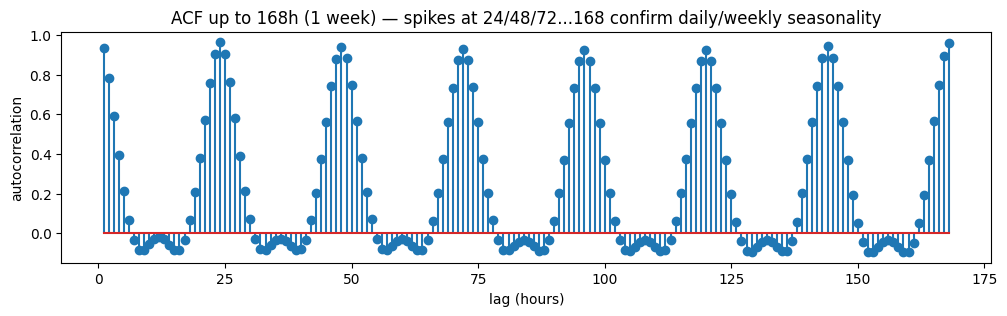

In [10]:
s = d.set_index("hour")["demand"]
lags = [1, 2, 24, 48, 72, 168, 336]
print("Lag autocorrelation:")
for lag in lags:
    print(f"  lag {lag:>4}h: {s.autocorr(lag):.3f}")

ac = [s.autocorr(lag) for lag in range(1, 169)]
plt.figure(figsize=(12, 3))
plt.stem(range(1, 169), ac)
plt.title("ACF up to 168h (1 week) — spikes at 24/48/72...168 confirm daily/weekly seasonality")
plt.xlabel("lag (hours)")
plt.ylabel("autocorrelation")
plt.show()

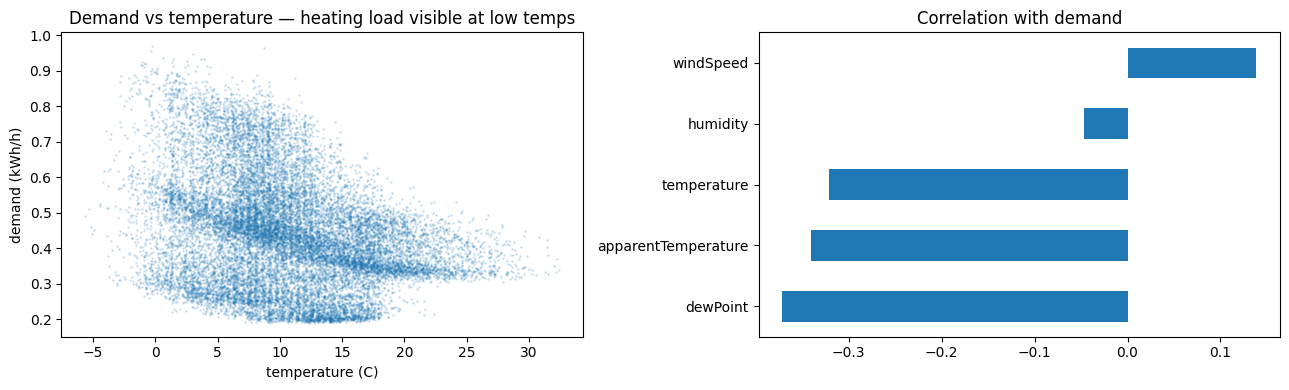

demand                 1.000000
temperature           -0.321632
apparentTemperature   -0.340874
humidity              -0.046464
windSpeed              0.138599
dewPoint              -0.371365
Name: demand, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(d["temperature"], d["demand"], s=1, alpha=0.15)
axes[0].set_xlabel("temperature (C)")
axes[0].set_ylabel("demand (kWh/h)")
axes[0].set_title("Demand vs temperature — heating load visible at low temps")

corr = d[["demand", "temperature", "apparentTemperature", "humidity", "windSpeed", "dewPoint"]].corr()["demand"]
corr.drop("demand").sort_values().plot.barh(ax=axes[1], title="Correlation with demand")
plt.tight_layout()
plt.show()
print(corr)

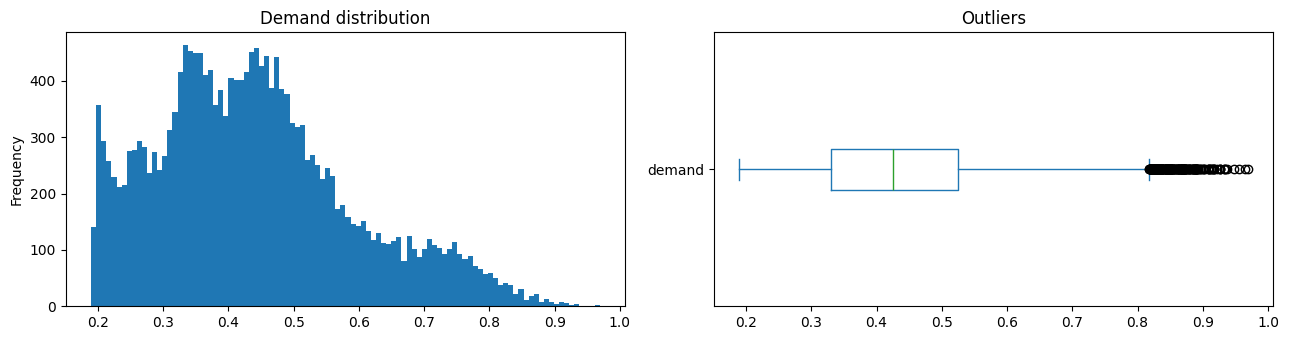

p99 = 0.829 kWh | spike hours: 199
Spike months: {1: 76, 2: 63, 3: 18, 11: 1, 12: 41}


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
d["demand"].plot.hist(bins=100, ax=axes[0], title="Demand distribution")
d["demand"].plot.box(ax=axes[1], vert=False, title="Outliers")
plt.tight_layout()
plt.show()

q99 = d["demand"].quantile(0.99)
spikes = d[d["demand"] > q99]
print(f"p99 = {q99:.3f} kWh | spike hours: {len(spikes)}")
print("Spike months:", spikes["hour"].dt.month.value_counts().sort_index().to_dict())